# Étape 3 — Feature engineering

Entrée : `data/patients_nutrition_clean.csv` (18 colonnes).
Sortie : `data/patients_nutrition_features.csv`.

Indicateurs dérivés retenus : `bmi_category` (seuils OMS), `protein_per_kg`, et un
score de triage `risk_screen_score` (composite de 4 drapeaux). Deux pistes sont
écartées et documentées : le découpage de `follow_up_weeks` en tranches et une
ancienneté calendaire.

Règle héritée de l'étape 2 : toute feature dérivée d'une colonne imputée porte un
marqueur `_imputed` ou ne se calcule que sur donnée observée.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 150)
sns.set_theme(style="whitegrid")

df = pd.read_csv("../data/patients_nutrition_clean.csv", parse_dates=["admission_date"])
df.shape


(2500, 18)

## F1 — `bmi_category` (seuils OMS)

Insuffisance pondérale < 18,5 ≤ Corpulence normale < 25 ≤ Surpoids < 30 ≤ Obésité.
Catégorielle ordonnée. `bmi` n'a été ni imputé ni corrigé (cohérence vérifiée à
l'étape 1) : aucune dépendance `_imputed`.


In [2]:
oms_labels = ["Insuffisance pondérale", "Corpulence normale", "Surpoids", "Obésité"]
df["bmi_category"] = pd.cut(
    df["bmi"], bins=[-np.inf, 18.5, 25, 30, np.inf], labels=oms_labels, right=False
).astype(pd.CategoricalDtype(categories=oms_labels, ordered=True))

print(df["bmi_category"].value_counts().reindex(oms_labels))
print("\nValeurs manquantes :", int(df["bmi_category"].isna().sum()))


bmi_category
Insuffisance pondérale      67
Corpulence normale        1513
Surpoids                   852
Obésité                     68
Name: count, dtype: int64

Valeurs manquantes : 0


In [3]:
ct = pd.crosstab(df["bmi_category"], df["condition"])
print("bmi_category (IMC mesuré) x condition (diagnostic saisi) :")
print(ct)
print("\nPatients avec bmi_category = Obésité :", int((df["bmi_category"] == "Obésité").sum()))
print("Patients avec condition = Obésité   :", int((df["condition"] == "Obésité").sum()))


bmi_category (IMC mesuré) x condition (diagnostic saisi) :
condition               Aucune  Diabète type 2  Hypertension  Insuffisance rénale  Non renseigné  Obésité
bmi_category                                                                                             
Insuffisance pondérale      31               9            11                    4              1       11
Corpulence normale         571             343           266                  107             15      211
Surpoids                   347             169           161                   51              9      115
Obésité                     24              17            11                    5              0       11

Patients avec bmi_category = Obésité : 68
Patients avec condition = Obésité   : 348


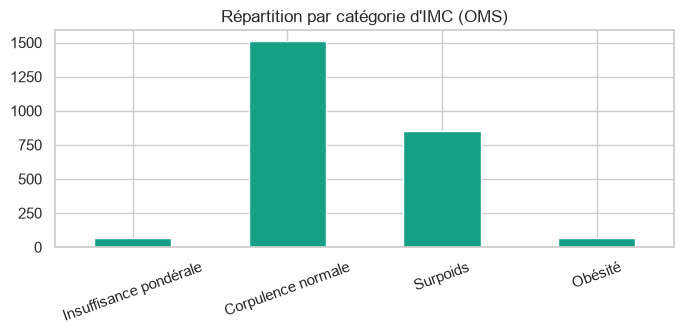

In [4]:
fig, ax = plt.subplots(figsize=(7, 3.5))
df["bmi_category"].value_counts().reindex(oms_labels).plot.bar(ax=ax, color="#16a085")
ax.set_title("Répartition par catégorie d'IMC (OMS)")
ax.set_xlabel("")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


## F2 — `protein_per_kg`

`daily_protein_g / weight_kg`. L'adéquation protéique se juge par kg de poids
corporel (apport de référence adulte OMS/EFSA ≈ 0,8 g/kg/j), pas en grammes absolus.

Dépend de `daily_protein_g` (imputé sur 104 lignes) ; `weight_kg` jamais imputé.
`protein_per_kg_imputed` reprend `daily_protein_g_imputed`.


In [5]:
df["protein_per_kg"] = df["daily_protein_g"] / df["weight_kg"]
df["protein_per_kg_imputed"] = df["daily_protein_g_imputed"]

print(df["protein_per_kg"].describe().round(3))
print("\n< 0,8 g/kg :", int((df["protein_per_kg"] < 0.8).sum()),
      "  dont sur valeur imputée :", int(((df["protein_per_kg"] < 0.8) & df["protein_per_kg_imputed"]).sum()))


count    2500.000
mean        0.994
std         0.334
min         0.076
25%         0.773
50%         0.971
75%         1.182
max         2.694
Name: protein_per_kg, dtype: float64

< 0,8 g/kg : 689   dont sur valeur imputée : 2


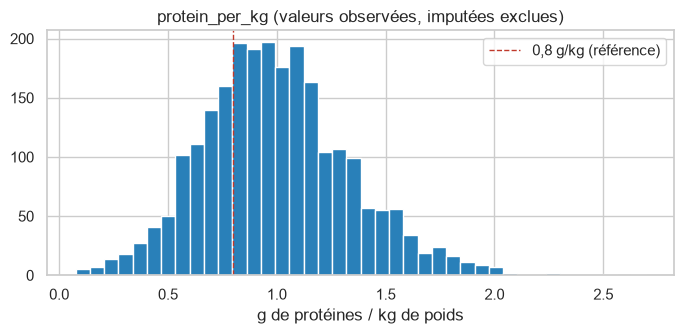

In [6]:
obs = df.loc[~df["protein_per_kg_imputed"], "protein_per_kg"]
fig, ax = plt.subplots(figsize=(7, 3.5))
ax.hist(obs, bins=40, color="#2980b9", edgecolor="white")
ax.axvline(0.8, color="#c0392b", ls="--", lw=1, label="0,8 g/kg (référence)")
ax.set_title("protein_per_kg (valeurs observées, imputées exclues)")
ax.set_xlabel("g de protéines / kg de poids")
ax.legend()
plt.tight_layout()
plt.show()


## F3 — `risk_screen_score` (composite de triage)

Nombre de signaux d'alerte diététiques cumulés, pour **prioriser la revue de
dossiers** — pas un diagnostic ni un score de gravité. Chaque drapeau est un seuil
transparent, exposé séparément.

| Drapeau | Règle | Seuil |
|---|---|---|
| `flag_underweight_or_obese` | `bmi_category` ∈ {Insuffisance pondérale, Obésité} | seuils OMS |
| `flag_protein_low` | `protein_per_kg` < 0,8 | référence OMS/EFSA adulte |
| `flag_sodium_high_cardiorenal` | `daily_sodium_mg` > 3500 et `condition` ∈ {Hypertension, Insuffisance rénale} | cible < 2000–2300 mg pour ces pathologies |
| `flag_weight_change_marked` | `abs(weight_change_pct)` > 5 | variation pondérale cliniquement notable |

Les drapeaux 2 à 4 ne sont levés que sur donnée observée (`& ~*_imputed`).
`risk_screen_incomplete` marque les patients dont une colonne contributrice a été
imputée : leur score peut être sous-estimé.


In [7]:
cardiorenal = df["condition"].isin(["Hypertension", "Insuffisance rénale"])

df["flag_underweight_or_obese"] = df["bmi_category"].isin(["Insuffisance pondérale", "Obésité"])
df["flag_protein_low"] = (df["protein_per_kg"] < 0.8) & ~df["daily_protein_g_imputed"]
df["flag_sodium_high_cardiorenal"] = (df["daily_sodium_mg"] > 3500) & cardiorenal & ~df["daily_sodium_mg_imputed"]
df["flag_weight_change_marked"] = (df["weight_change_pct"].abs() > 5) & ~df["weight_change_pct_imputed"]

flag_cols = [
    "flag_underweight_or_obese",
    "flag_protein_low",
    "flag_sodium_high_cardiorenal",
    "flag_weight_change_marked",
]
df["risk_screen_score"] = df[flag_cols].sum(axis=1).astype(int)

df["risk_screen_incomplete"] = (
    df["daily_protein_g_imputed"]
    | (cardiorenal & df["daily_sodium_mg_imputed"])
    | df["weight_change_pct_imputed"]
)

print("Drapeaux levés (donnée observée) :")
print(df[flag_cols].sum())
print("\nDistribution du score :")
print(df["risk_screen_score"].value_counts().sort_index())
print("\nscore >= 2 :", int((df["risk_screen_score"] >= 2).sum()),
      " | dont complet :", int(((df["risk_screen_score"] >= 2) & ~df["risk_screen_incomplete"]).sum()))
print("risk_screen_incomplete :", int(df["risk_screen_incomplete"].sum()))


Drapeaux levés (donnée observée) :
flag_underweight_or_obese       135
flag_protein_low                687
flag_sodium_high_cardiorenal    130
flag_weight_change_marked       264
dtype: int64

Distribution du score :
risk_screen_score
0    1438
1     911
2     148
3       3
Name: count, dtype: int64

score >= 2 : 151  | dont complet : 140
risk_screen_incomplete : 351


                       n  part_score_ge_1  score_moyen
condition                                             
Aucune               973             0.41         0.46
Diabète type 2       538             0.34         0.38
Hypertension         449             0.54         0.66
Insuffisance rénale  167             0.51         0.65
Non renseigné         25             0.40         0.52
Obésité              348             0.42         0.43


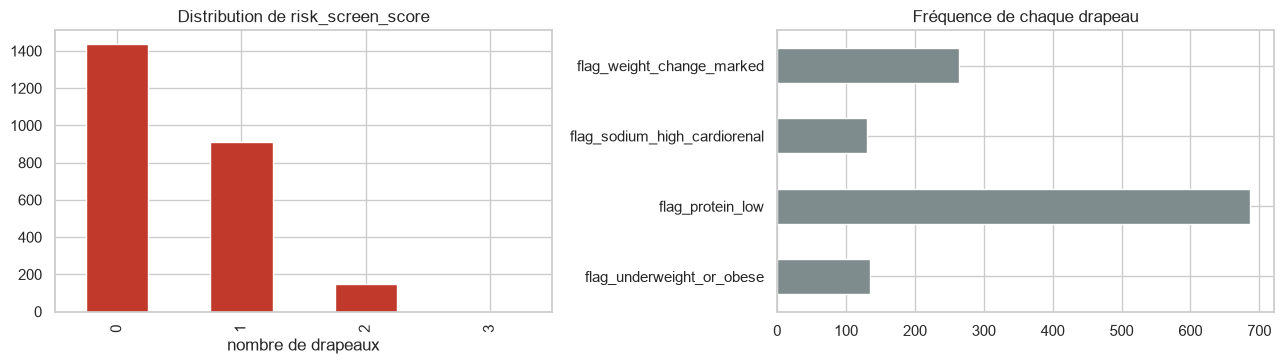

In [8]:
summary = df.groupby("condition").agg(
    n=("patient_id", "size"),
    part_score_ge_1=("risk_screen_score", lambda s: (s >= 1).mean().round(2)),
    score_moyen=("risk_screen_score", lambda s: s.mean().round(2)),
)
print(summary)

fig, axes = plt.subplots(1, 2, figsize=(13, 3.8))
df["risk_screen_score"].value_counts().sort_index().plot.bar(ax=axes[0], color="#c0392b")
axes[0].set_title("Distribution de risk_screen_score")
axes[0].set_xlabel("nombre de drapeaux")
df[flag_cols].sum().plot.barh(ax=axes[1], color="#7f8c8d")
axes[1].set_title("Fréquence de chaque drapeau")
plt.tight_layout()
plt.show()


## Piste écartée — Tranches de `follow_up_weeks`

Vérification de l'intérêt d'un découpage en tranches (comme `tenure_group` sur un
projet de churn).


follow_up_weeks : min 1 max 25 moyenne 13.0
Test chi2 d'uniformité sur 1..25 : p = 0.489

Corrélations de follow_up_weeks avec :
nutritionist_visits     -0.037
weight_change_pct       -0.005
daily_calories          -0.027
mois_depuis_admission   -0.022
dtype: float64


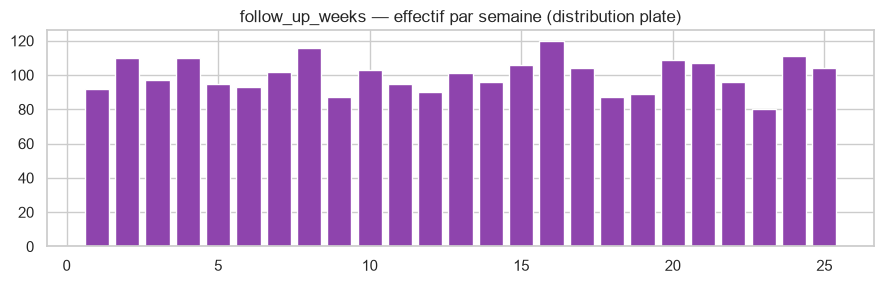

In [9]:
fu = df["follow_up_weeks"]
counts = fu.value_counts().sort_index()
chi2_p = stats.chisquare(counts.values).pvalue

print("follow_up_weeks : min", fu.min(), "max", fu.max(), "moyenne", round(fu.mean(), 1))
print("Test chi2 d'uniformité sur 1..25 : p =", round(chi2_p, 3))
print("\nCorrélations de follow_up_weeks avec :")
today = pd.Timestamp("2026-09-07")
months_since = (today - df["admission_date"]).dt.days / 30.44
print(pd.Series({
    "nutritionist_visits": fu.corr(df["nutritionist_visits"]),
    "weight_change_pct": fu.corr(df["weight_change_pct"]),
    "daily_calories": fu.corr(df["daily_calories"]),
    "mois_depuis_admission": fu.corr(months_since),
}).round(3))

fig, ax = plt.subplots(figsize=(9, 3))
ax.bar(counts.index, counts.values, color="#8e44ad")
ax.set_title("follow_up_weeks — effectif par semaine (distribution plate)")
plt.tight_layout()
plt.show()


Distribution indistinguable d'une loi uniforme (p ≈ 0,49), aucune corrélation avec
les visites, l'évolution du poids ou la durée calendaire. Un découpage donnerait des
bornes arbitraires et des groupes qui ne se distinguent sur aucun indicateur —
contrairement à une tenure de churn, typiquement asymétrique et prédictive.
**Feature non créée.**

## Piste écartée — Ancienneté calendaire

`mois_depuis_admission` mesure autre chose que `follow_up_weeks` (2–20 mois vs
0,25–6 mois), mais dépend d'une date de référence « aujourd'hui » arbitraire sur un
dataset synthétique : elle décrirait une file active fictive, dérivant à chaque
consultation du dashboard. `admission_date` est conservée telle quelle pour les vues
temporelles (admissions par mois). **Feature non créée.**


## Validation et export

In [10]:
new_cols = [
    "bmi_category", "protein_per_kg", "protein_per_kg_imputed",
    *flag_cols, "risk_screen_score", "risk_screen_incomplete",
]
print("Colonnes ajoutées :", new_cols)
print("Dimensions :", df.shape)
print("Valeurs manquantes sur les nouvelles colonnes :")
print(df[new_cols].isna().sum())

df.to_csv("../data/patients_nutrition_features.csv", index=False)
print("\nÉcrit : data/patients_nutrition_features.csv", df.shape)


Colonnes ajoutées : ['bmi_category', 'protein_per_kg', 'protein_per_kg_imputed', 'flag_underweight_or_obese', 'flag_protein_low', 'flag_sodium_high_cardiorenal', 'flag_weight_change_marked', 'risk_screen_score', 'risk_screen_incomplete']
Dimensions : (2500, 27)
Valeurs manquantes sur les nouvelles colonnes :
bmi_category                    0
protein_per_kg                  0
protein_per_kg_imputed          0
flag_underweight_or_obese       0
flag_protein_low                0
flag_sodium_high_cardiorenal    0
flag_weight_change_marked       0
risk_screen_score               0
risk_screen_incomplete          0
dtype: int64



Écrit : data/patients_nutrition_features.csv (2500, 27)


## Observations

- **`bmi_category`** (OMS, ordonnée) : Corpulence normale 1513, Surpoids 852,
  Obésité 68, Insuffisance pondérale 67. Aucune valeur manquante. À ne pas confondre
  avec `condition = Obésité` (348 patients, diagnostic distinct de l'IMC mesuré).
- **`protein_per_kg`** : médiane ≈ 0,97 g/kg ; 687 patients sous 0,8 g/kg (référence
  adulte). `protein_per_kg_imputed` hérité de `daily_protein_g_imputed` (104 lignes).
- **`risk_screen_score`** (0–4) : 1438 patients à 0, 911 à 1, 148 à 2, 3 à 3.
  Score ≥ 2 = 151 patients (6 %), dont 140 sur données complètes.
  `risk_screen_incomplete` = 351. Drapeaux exposés individuellement
  (`flag_*`). Cadré comme outil de tri, pas de diagnostic.
- **Écarté** : tranches de `follow_up_weeks` (distribution uniforme, p ≈ 0,49, non
  corrélée à quoi que ce soit) ; ancienneté calendaire (dépend d'un « aujourd'hui »
  arbitraire sur suivi simulé).
- **Sortie** : `data/patients_nutrition_features.csv`, 2500 lignes × 27 colonnes,
  0 valeur manquante sur les colonnes dérivées.
